### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [37]:
import tensorflow as tf
from tensorflow import data
from tensorflow.keras.applications import ResNet50, Xception, VGG16
from tensorflow.keras import layers, Model, optimizers, callbacks, utils, models

In [5]:
import albumentations as A

### Step 2: Constant

In [69]:
AUTO = data.experimental.AUTOTUNE
DATA_FOLD = './data/COVID-19_from_Chest_X-Ray/'
IMG_HEIGH = 256
IMG_WIDTH = 256
IMG_CHANNEL = 3
BATCH_SIZE = 64
EPOCHS = 30
PRE_MODEL = 'vgg16'
NUM_CLASSES = 2

### Step 3: Load Data

In [7]:
labels = os.listdir(DATA_FOLD)

In [8]:
df = pd.DataFrame()
for label in labels:
    temp = pd.DataFrame(
        {
            'img_id': os.listdir(f'{DATA_FOLD}{label}'),
            'label': label
        }
    )
    df = pd.concat([df, temp], ignore_index=True)

In [9]:
df.sample(5)

,img_id,label
102,Covid (1090).png,COVID
1720,Non-Covid (313).png,non-COVID
619,Covid (429).png,COVID
2079,Non-Covid (637).png,non-COVID
910,Covid (691).png,COVID


### Step 4: Exploaring Data

#### Target Distribution

In [10]:
temp = df['label'].value_counts()

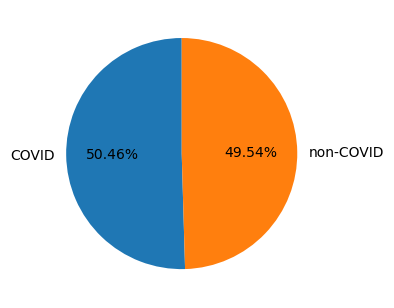

In [11]:
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index,
    startangle=90
)
plt.tight_layout()

#### Show Image

In [12]:
temp = A.Resize(IMG_HEIGH, IMG_WIDTH)

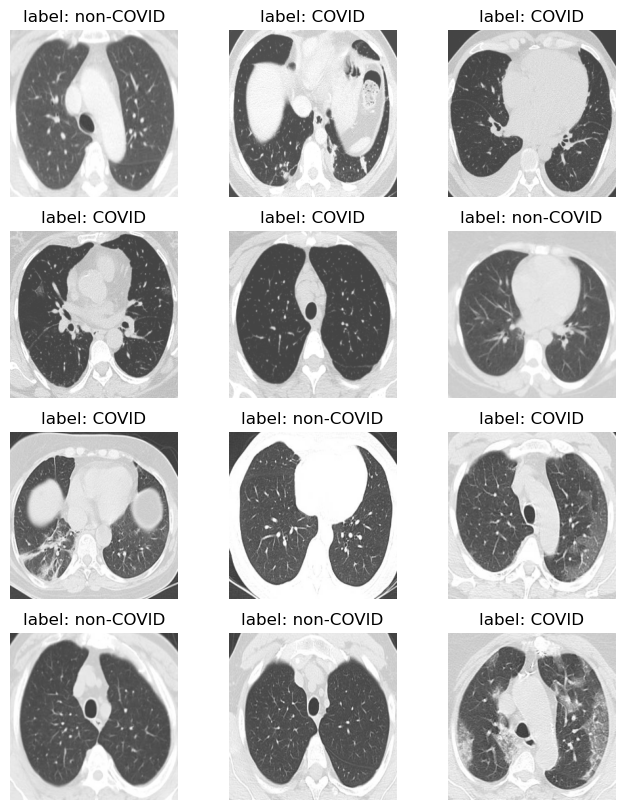

In [13]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    k = np.random.randint(df.shape[0])
    label = df.loc[k, 'label']
    img_id = df.loc[k, 'img_id']
    img = plt.imread(f'{DATA_FOLD}{label}/{img_id}')
    img = temp(image=img)['image']
    plt.imshow(img)
    plt.title(f'label: {label}')
    plt.axis('off')

### Step 5: Preparing Data

#### Label Encode

In [14]:
le = LabelEncoder()

In [15]:
df['label_id'] = le.fit_transform(df['label'])

#### Split Data

In [16]:
train, value = train_test_split(
    df,
    test_size=0.4,
    random_state=42
)

In [17]:
value, test = train_test_split(
    value,
    test_size=0.5,
    random_state=42
)

In [18]:
print(len(train), len(value), len(test))

1488 496 497


#### Albumentation

In [19]:
preparing = A.Resize(IMG_HEIGH, IMG_WIDTH)

In [20]:
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomGamma(p=0.2),
        A.RandomBrightnessContrast(p=0.2),
        A.CoarseDropout(p=0.2)        
    ]
)

#### Build Generator

In [21]:
def generator(df, img_shape, is_train):
    def gen():
        for _, row in df.iterrows():
            img_id = row['img_id']
            label = row['label']
            label_id = row['label_id']
            img = cv2.imread(f'{DATA_FOLD}{label}/{img_id}')
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = preparing(image=img)['image']
            if is_train:
                img = transform(image=img)['image']
            img = img.astype('float32') / 255.0
            yield img, label_id
    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [22]:
def get_generator(df, img_shape, batch_size, is_train=True):
    gen = generator(df, img_shape, is_train)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, len(le.classes_)))
    )
    if is_train:
        gen = gen.shuffle(min(len(df), 1000))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [23]:
train_generator = get_generator(train, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)
test_generator = get_generator(test, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)

In [24]:
for img, label in train_generator.take(1):
    print(img.shape, label.shape)

(64, 256, 256, 3) (64, 2)


### Step 6: Model Development

In [25]:
history_dict = dict()

#### Build Model

In [70]:
if PRE_MODEL == 'resnet50':
    pre_trained_model = ResNet50(input_shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), weights='imagenet', include_top=False)
elif PRE_MODEL == 'xception':
    pre_trained_model = Xception(input_shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), weights='imagenet', include_top=False)
elif PRE_MODEL == 'vgg16':
    pre_trained_model = VGG16(input_shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), weights='imagenet', include_top=False)
else:
    raise NotImplementedError('Pre train model should in {}'.format(', '.join(['resnet50', 'xception', 'vgg16'])))

In [71]:
pre_trained_model.trainable = False

In [72]:
inputs = layers.Input(shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL))
x = layers.Conv2D(3, 3, padding='same')(inputs)
x = pre_trained_model(x)
# x = layers.GlobalAveragePooling2D()(pre_trained_model.output)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

In [73]:
model = Model(inputs, outputs)

In [30]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 256, 256, 3)         │              84 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 8, 8, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,623,550 (90.12 MB)

 Trainable params: 2,758,486 (10.52 MB)

 Non-trainable params: 20,865,064 (79.59 MB)

In [31]:
utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    show_layer_activations=True,
    show_trainable=True
)

#### Compile Model

In [74]:
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [75]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

#### Train Model

In [76]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [77]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=0
)

In [78]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 252s 10s/step - accuracy: 0.7036 - loss: 0.8023 - val_accuracy: 0.5081 - val_loss: 0.7157 - learning_rate: 0.0010
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 287s 12s/step - accuracy: 0.7789 - loss: 0.6225 - val_accuracy: 0.5302 - val_loss: 0.6801 - learning_rate: 0.0010
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 296s 12s/step - accuracy: 0.7991 - loss: 0.5025 - val_accuracy: 0.5101 - val_loss: 0.6895 - learning_rate: 0.0010
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 296s 12s/step - accuracy: 0.8374 - loss: 0.4289 - val_accuracy: 0.5081 - val_loss: 0.8052 - learning_rate: 0.0010
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 297s 12s/step - accuracy: 0.8427 - loss: 0.4076 - val_accuracy: 0.5363 - val_loss: 0.6664 - learning_rate: 0.0010
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 298s 12s/step - accuracy: 0.8522 - loss: 0.3671 - val_accuracy: 0.5222 - val_loss: 0.7346 - learning_rate: 0.0010
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 297s 12s/step - accuracy: 0.8488 - loss: 0.3686 - 

In [79]:
model.save(f'./json/{PRE_MODEL}.keras')

In [80]:
history_dict[PRE_MODEL] = history

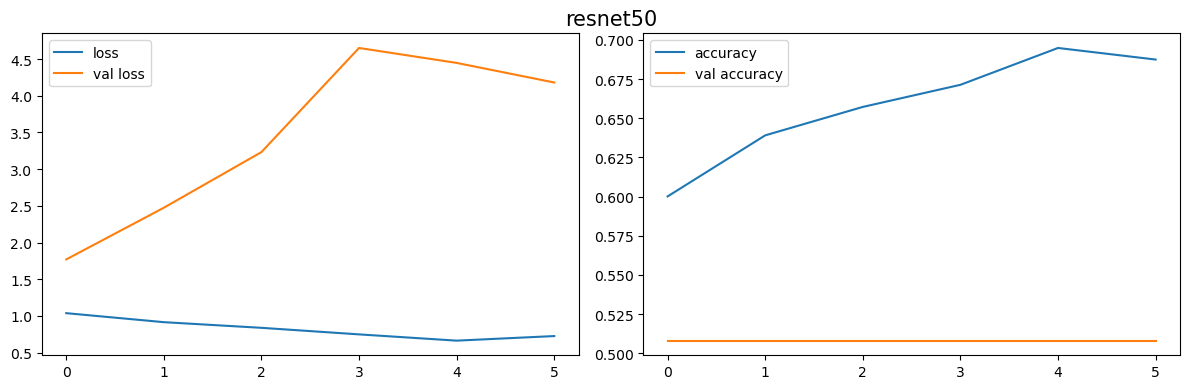

In [81]:
plt.figure(figsize=(12, 4))
plt.title('resnet50', fontsize=15)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.plot(history_dict['resnet50'].history['loss'], label='loss')
plt.plot(history_dict['resnet50'].history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_dict['resnet50'].history['accuracy'], label='accuracy')
plt.plot(history_dict['resnet50'].history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

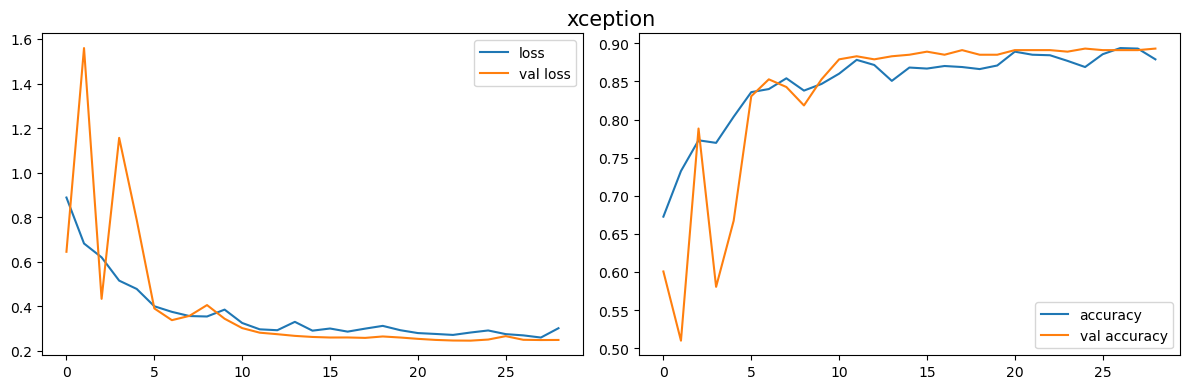

In [82]:
plt.figure(figsize=(12, 4))
plt.title('xception', fontsize=15)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.plot(history_dict['xception'].history['loss'], label='loss')
plt.plot(history_dict['xception'].history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_dict['xception'].history['accuracy'], label='accuracy')
plt.plot(history_dict['xception'].history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

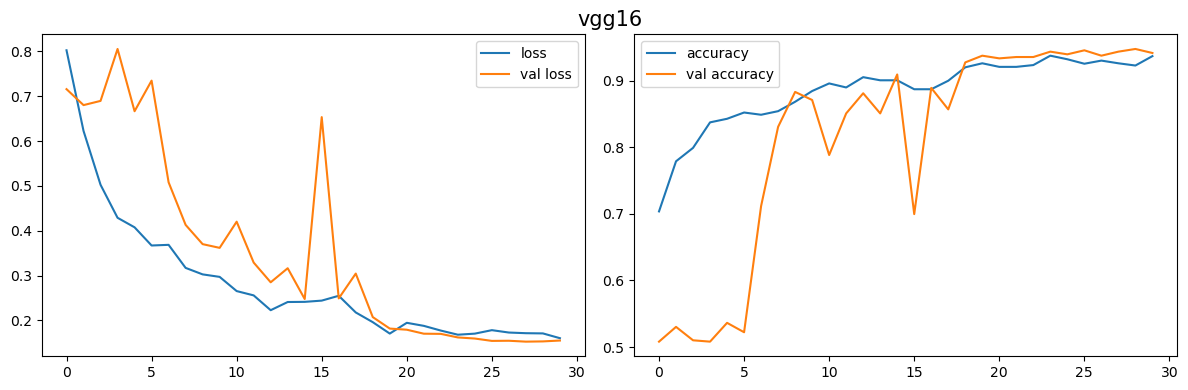

In [83]:
plt.figure(figsize=(12, 4))
plt.title('vgg16', fontsize=15)
plt.axis('off')
plt.subplot(1, 2, 1)
plt.plot(history_dict['vgg16'].history['loss'], label='loss')
plt.plot(history_dict['vgg16'].history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_dict['vgg16'].history['accuracy'], label='accuracy')
plt.plot(history_dict['vgg16'].history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [84]:
model = models.load_model('./json/xception.keras')

In [85]:
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(accuracy, 3)}')

test loss: 0.294, test accuracy: 0.887


In [86]:
test_pred = model.predict(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


In [87]:
confuse_matrix = metrics.confusion_matrix(test['label_id'], np.argmax(test_pred, axis=1))

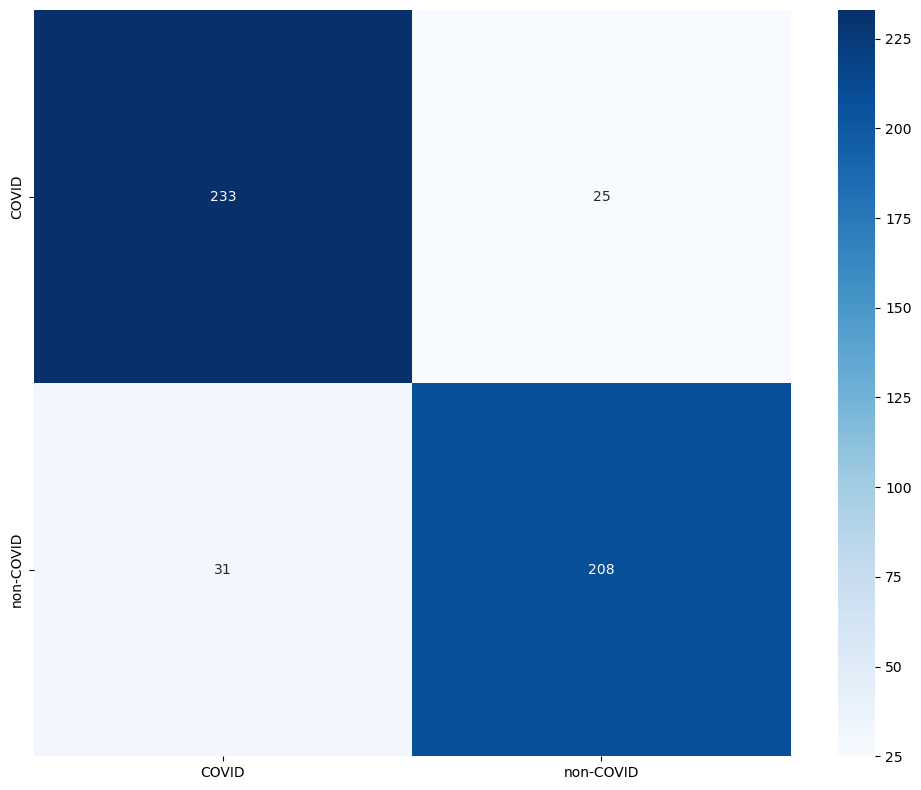

In [88]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.tight_layout()

In [89]:
model = models.load_model('./json/vgg16.keras')

In [90]:
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(accuracy, 3)}')

test loss: 0.192, test accuracy: 0.922


In [91]:
test_pred = model.predict(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step


In [92]:
confuse_matrix = metrics.confusion_matrix(test['label_id'], np.argmax(test_pred, axis=1))

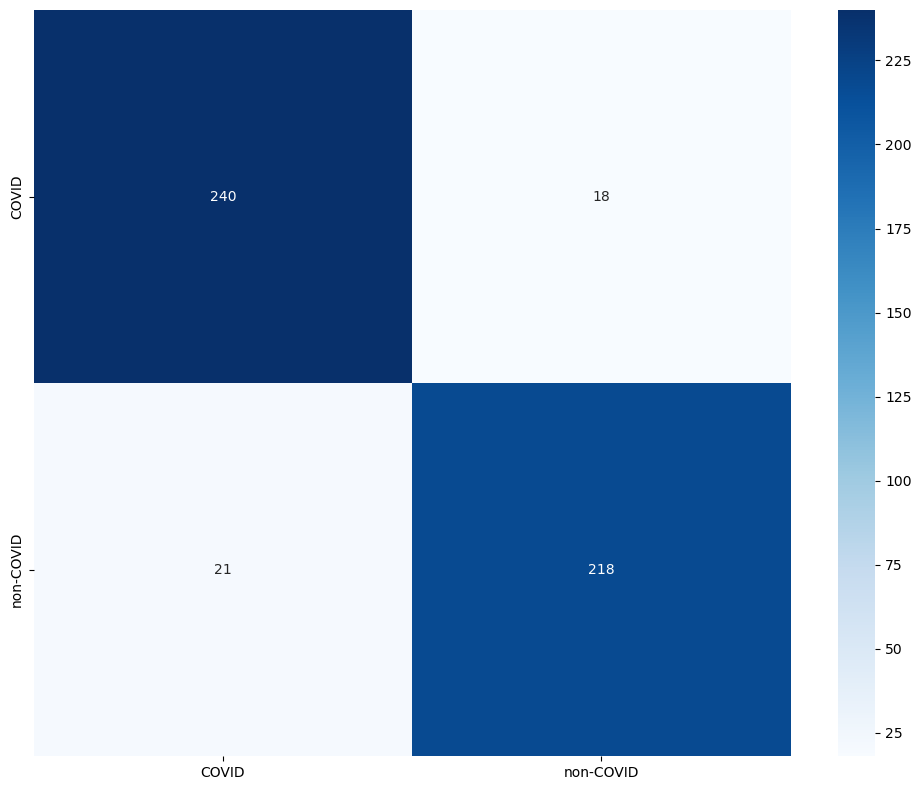

In [93]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.tight_layout()

In [94]:
model = models.load_model('./json/resnet50.keras')

In [95]:
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(accuracy, 3)}')

test loss: 1.731, test accuracy: 0.519


In [96]:
test_pred = model.predict(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


In [97]:
confuse_matrix = metrics.confusion_matrix(test['label_id'], np.argmax(test_pred, axis=1))

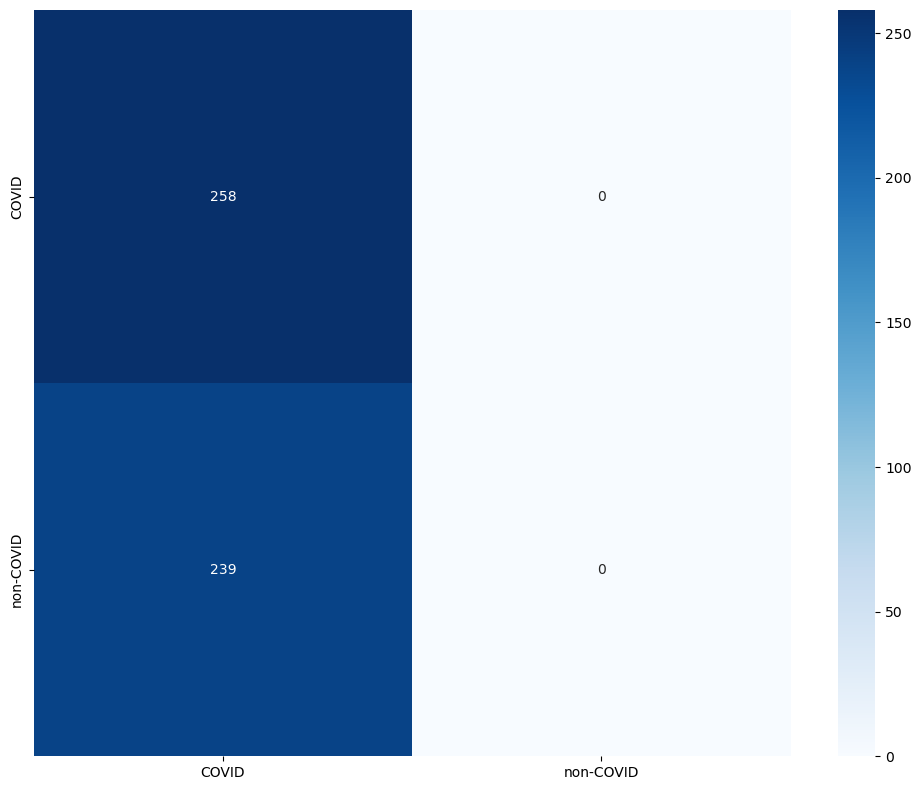

In [98]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.tight_layout()